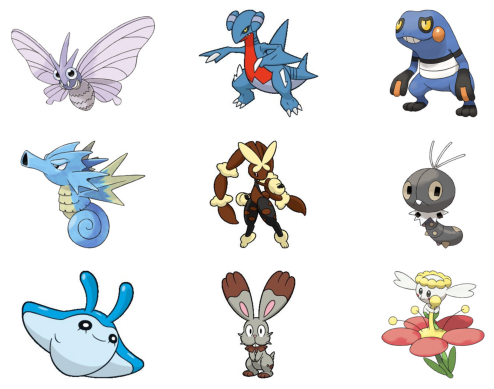

                         value
total images           2504.00
disk size (MB)           58.17
mean (height)           314.69
mean (width)            309.63
mean (total pixels)   97989.04
std (total pixels)    27902.74
min (total pixels)    18144.00
max (total pixels)   144000.00


In [56]:
import matplotlib.pyplot as plt 
from PIL import Image
import random 

from data import load_image_paths, compute_img_stats

dirpath = os.path.join(os.getcwd(), 'data/raw')

img_paths = load_image_paths(dirpath)

sample_paths = random.sample(img_paths, 9)

fig, axes = plt.subplots(3,3)
for ax, path in zip(axes.flatten(), sample_paths):
    with Image.open(path) as img:
        ax.imshow(img)
        ax.axis('off')

# view a random sample of 9 raw images
plt.show()

# view summary statistics for raw data
print(compute_img_stats(img_paths))

2026-05-01 11:52:58.559164: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9834176..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9811964..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.962837..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85840994..1.0].
Clipping input data to th

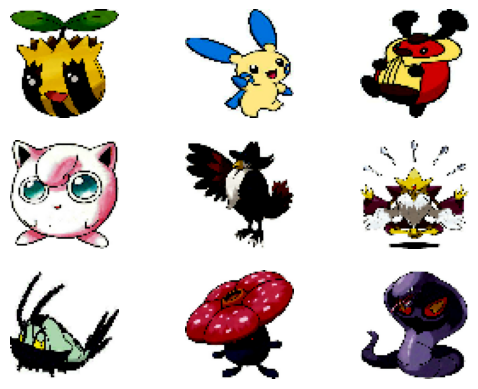

In [57]:
import sys
sys.path.append('src')

from preprocessing import preprocess_image, build_tf_dataset

dataset = build_tf_dataset(paths, batch_size=9)

images = []
for batch in dataset.take(1):
    for image in batch:
        images.append(image)

# view random sample of 9 processed images
fig, axes = plt.subplots(3,3)
for ax, img in zip(axes.flatten(), images):
    ax.imshow(img)
    ax.axis('off')
    


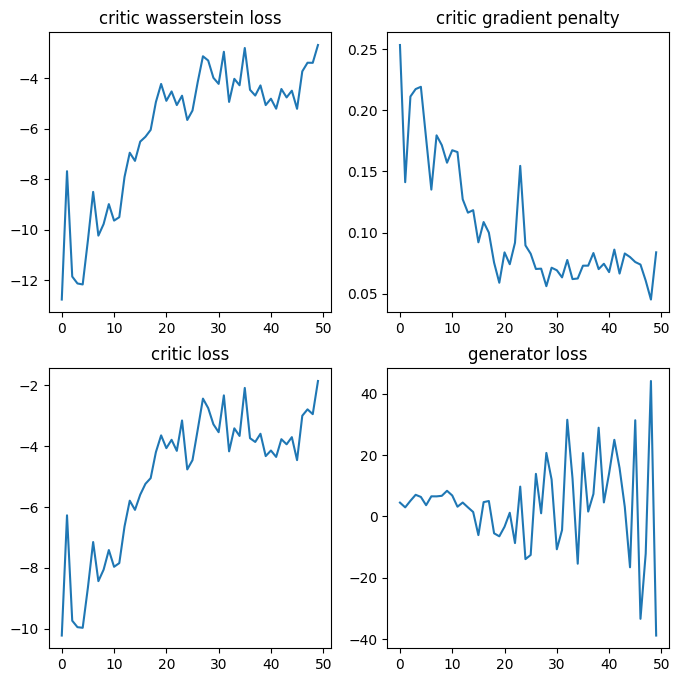

In [52]:
import pandas as pd 
import numpy as np 

# shows how to plot loss fucntions across epochs for WGAN model

data = pd.read_json('src/results/wgan_upsample_20260501_100239/history.json')
df = pd.DataFrame(data)

y1 = (df['c_wass_loss'], 'critic wasserstein loss')
y2 = (df['c_gp'], 'critic gradient penalty')
y3 = (df['c_loss'], 'critic loss')
y4 = (df['g_loss'], 'generator loss')

ys = [y1, y2, y3, y4]
#number of epochs
x = np.arange(50)
fig, axs = plt.subplots(2,2,figsize=(8,8))
axs = axs.flatten()

for i in range(4):
    axs[i].plot(x,ys[i][0])
    axs[i].set_title(ys[i][1])

plt.show()